# Adjust z

In [1]:
from astropy.io import fits
import astropy.constants as const
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from tqdm import tqdm
import warnings
import os
import sys
import json
from pathlib import Path
from useful_functions import *

In [2]:
data = fits.open('/Users/hyp0515/data/0715_Spring_BGS_ALL_trimmed.fits')
spectrum = Spectrum(data)

In [3]:
# spectrum.subtype_filter(subtype="QSO", exclude=True)

In [4]:
spectrum.add_attributes(['smoothed_flux'], [smooth_spectrum(spectrum.coadd_data, sigma=1)])
print(spectrum.smoothed_flux.shape)

(100638, 7781)


In [5]:
OII_rest    = air2vac(lines_air['OII'])
NII_rest    = air2vac(lines_air['NII'])
Hbeta_rest  = air2vac(lines_air['Hbeta'])
Halpha_rest = air2vac(lines_air['Halpha'])
SII_rest    = air2vac(lines_air['SII'])
CaII_rest   = air2vac(lines_air['CaII'])
NaD_rest    = air2vac(lines_air['NaD'])

39627758300567363
39627763748964089
39627775715312061
39627806128216016

In [57]:
example_targetID = 39627800000337419
example_index = spectrum.id2index(example_targetID)
targetid_example = spectrum.targetID[example_index]
flux = spectrum.smoothed_flux[example_index, :]
z = spectrum.z_pipe[example_index]

In [58]:
is_qso = check_bits(example_targetID, 2)
print(f'Is QSO? {is_qso}')

Is QSO? False


In [59]:
print(spectrum_link(targetid_example))

https://www.legacysurvey.org/viewer/desi-spectrum/dr1/targetid39627800000337419


In [60]:
# spectrum.mask_spectrum(example_index)

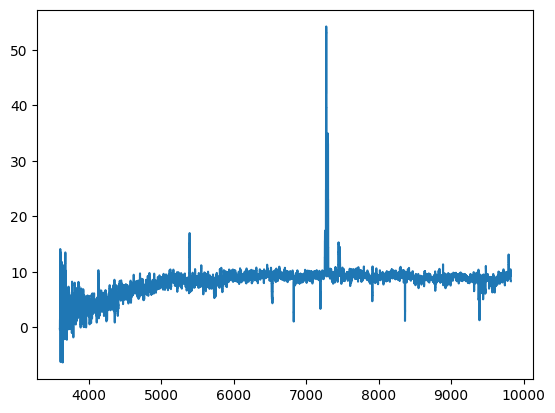

In [61]:
plt.step(desi_wavelength, flux, where='mid')
plt.show()

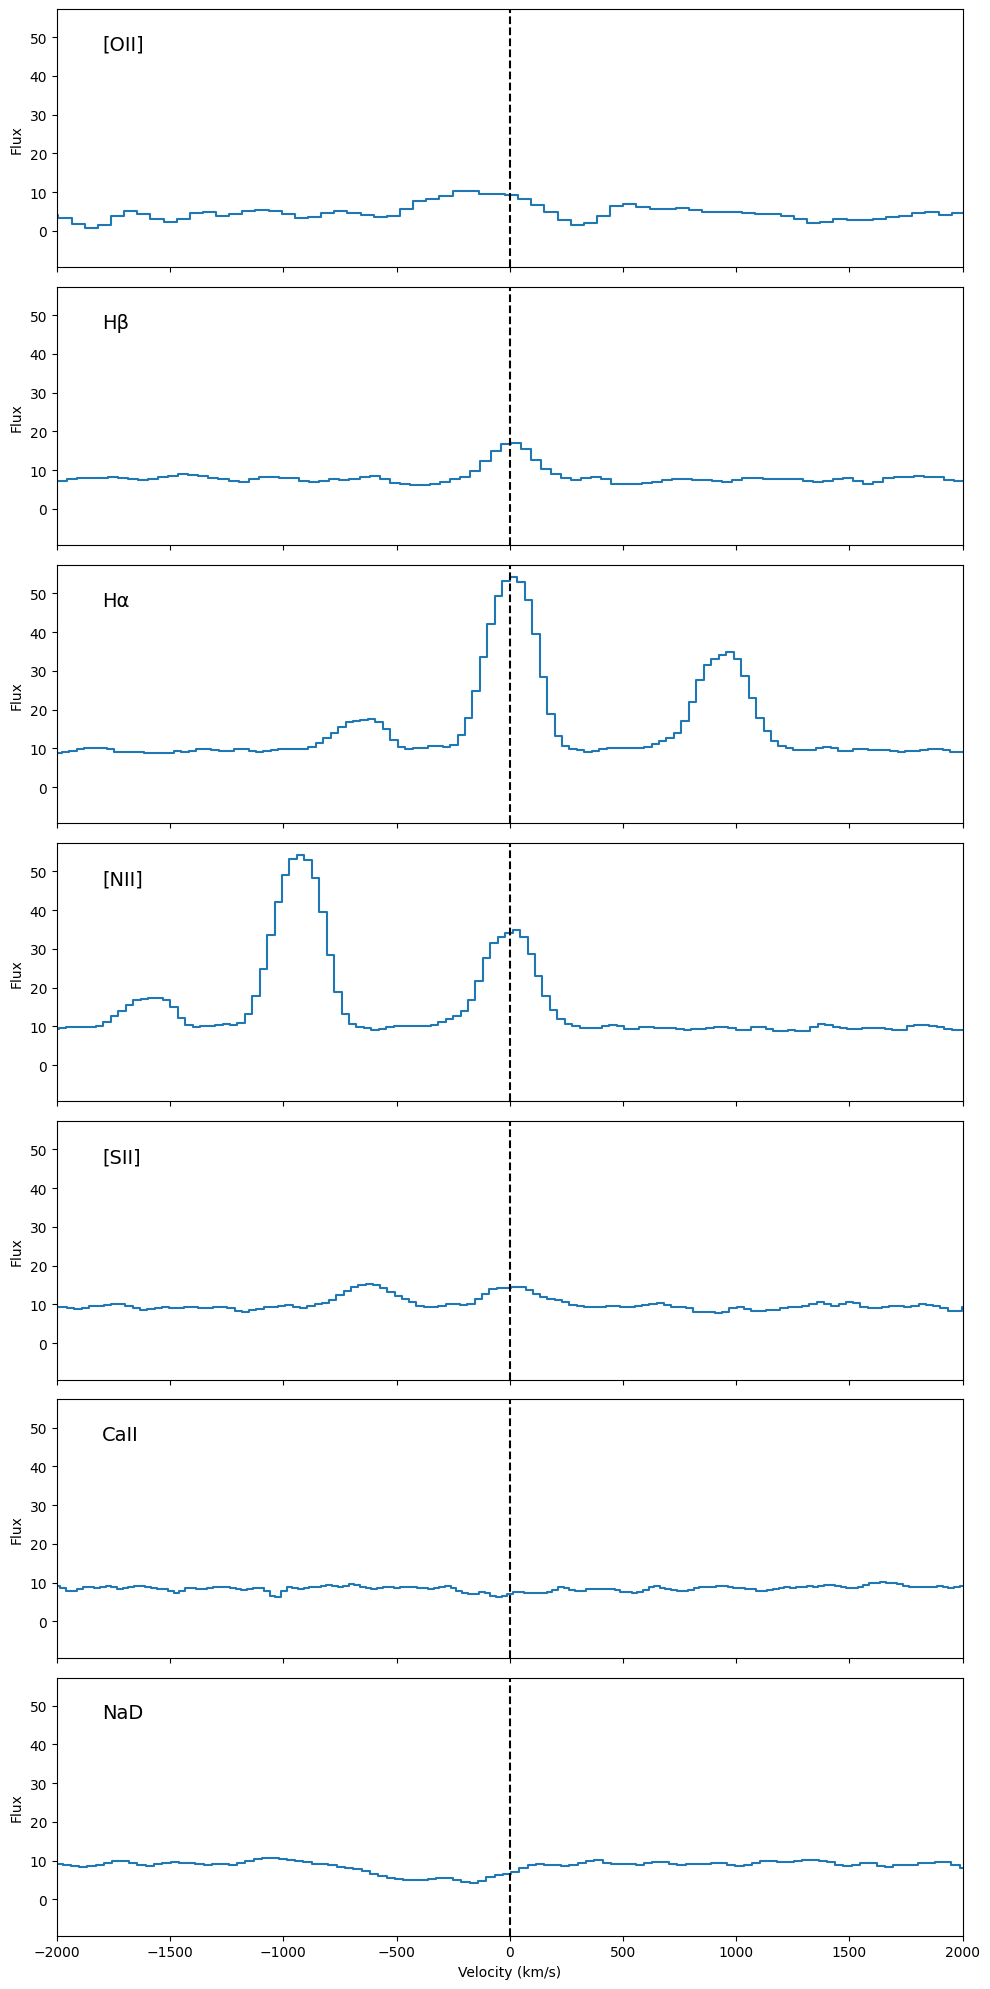

In [62]:
fig, ax = plt.subplots(7, 1, figsize=(10, 20), sharex=True)

ax[0].step(lam2vel(desi_wavelength, OII_rest[-1], z), flux, where='mid')
ax[1].step(lam2vel(desi_wavelength, Hbeta_rest, z), flux, where='mid')
ax[2].step(lam2vel(desi_wavelength, Halpha_rest, z), flux, where='mid')
ax[3].step(lam2vel(desi_wavelength, NII_rest[-1], z), flux, where='mid')
ax[4].step(lam2vel(desi_wavelength, SII_rest[-1], z), flux, where='mid')
ax[5].step(lam2vel(desi_wavelength, CaII_rest[-1], z), flux, where='mid')
ax[6].step(lam2vel(desi_wavelength, NaD_rest[-1], z), flux, where='mid')
for i in range(7):
    ax[i].text(0.05, 0.9, ['[OII]', 'Hβ', 'Hα', '[NII]', '[SII]', 'CaII', 'NaD'][i], transform=ax[i].transAxes, fontsize=14, verticalalignment='top')
    ax[i].set_xlim(-2000, 2000)
    ax[i].axvline(0, color='k', linestyle='--')
    ax[i].set_ylabel('Flux')
ax[-1].set_xlabel('Velocity (km/s)')
plt.tight_layout()
plt.show()

## Fit Halpha + NII

In [81]:
fit_line = [
    *Halpha_rest, 
    *NII_rest,
    # *SII_rest,
    # *OII_rest
]
mid_lam = np.mean(fit_line) * (1 + z)
region = (np.min(fit_line)*(1 + z)- 200, np.max(fit_line)*(1 + z) + 200)

(0.0, 40.0)

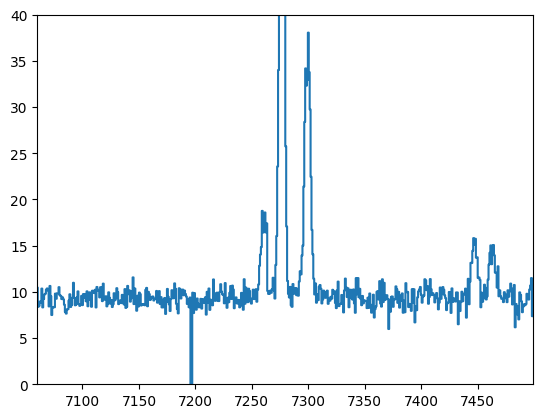

In [82]:
plt.step(desi_wavelength, spectrum.coadd_data[example_index], where='mid')
plt.axhline(mid_lam, color='k', linestyle='--')
plt.xlim(region[0], region[1])
plt.ylim(0, 40)

In [83]:
spectrum.fit_flux(i=example_index, fitting_model=model, lam0=fit_line, region=region, fit_z=True)
params = spectrum.fit_params[example_index, :]

print('dz: '+ f'{params[0]:3f}')
for i in range(len(fit_line)):
    print(f'Amp{i+1}: '+ f'{params[1+2*i]:.3f}')
    print(f'sigma{i+1}: '+ f'{params[2+2*i]:3f}')
print('Conti a: '+ f'{params[2]:3f}')
print('Conti b: '+ f'{params[-1]:3f}')

dz: 0.000010
Amp1: 48.898
sigma1: 2.293806
Amp2: 8.656
sigma2: 2.477387
Amp3: 27.652
sigma3: 2.519709
Conti a: 2.293806
Conti b: 0.000000


(0.0, 100.0)

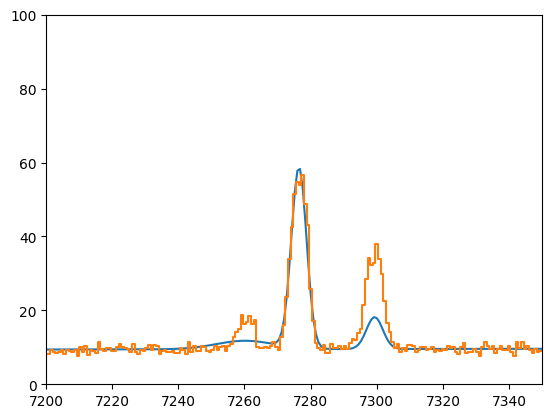

In [84]:
model_flux = model(desi_wavelength, 
                   gaussian_parms=[(params[i+1], fit_line[i]*(1+z+(params[0])), params[i+2]) for i in range(len(fit_line))], 
                   conti_parms=(params[-2], params[-1]))

plt.plot(desi_wavelength, (model_flux))
plt.step(desi_wavelength, (spectrum.coadd_data[example_index]), where='mid')
plt.xlim(region[0], region[1])
plt.xlim(7200, 7350)
plt.ylim(0, 100)

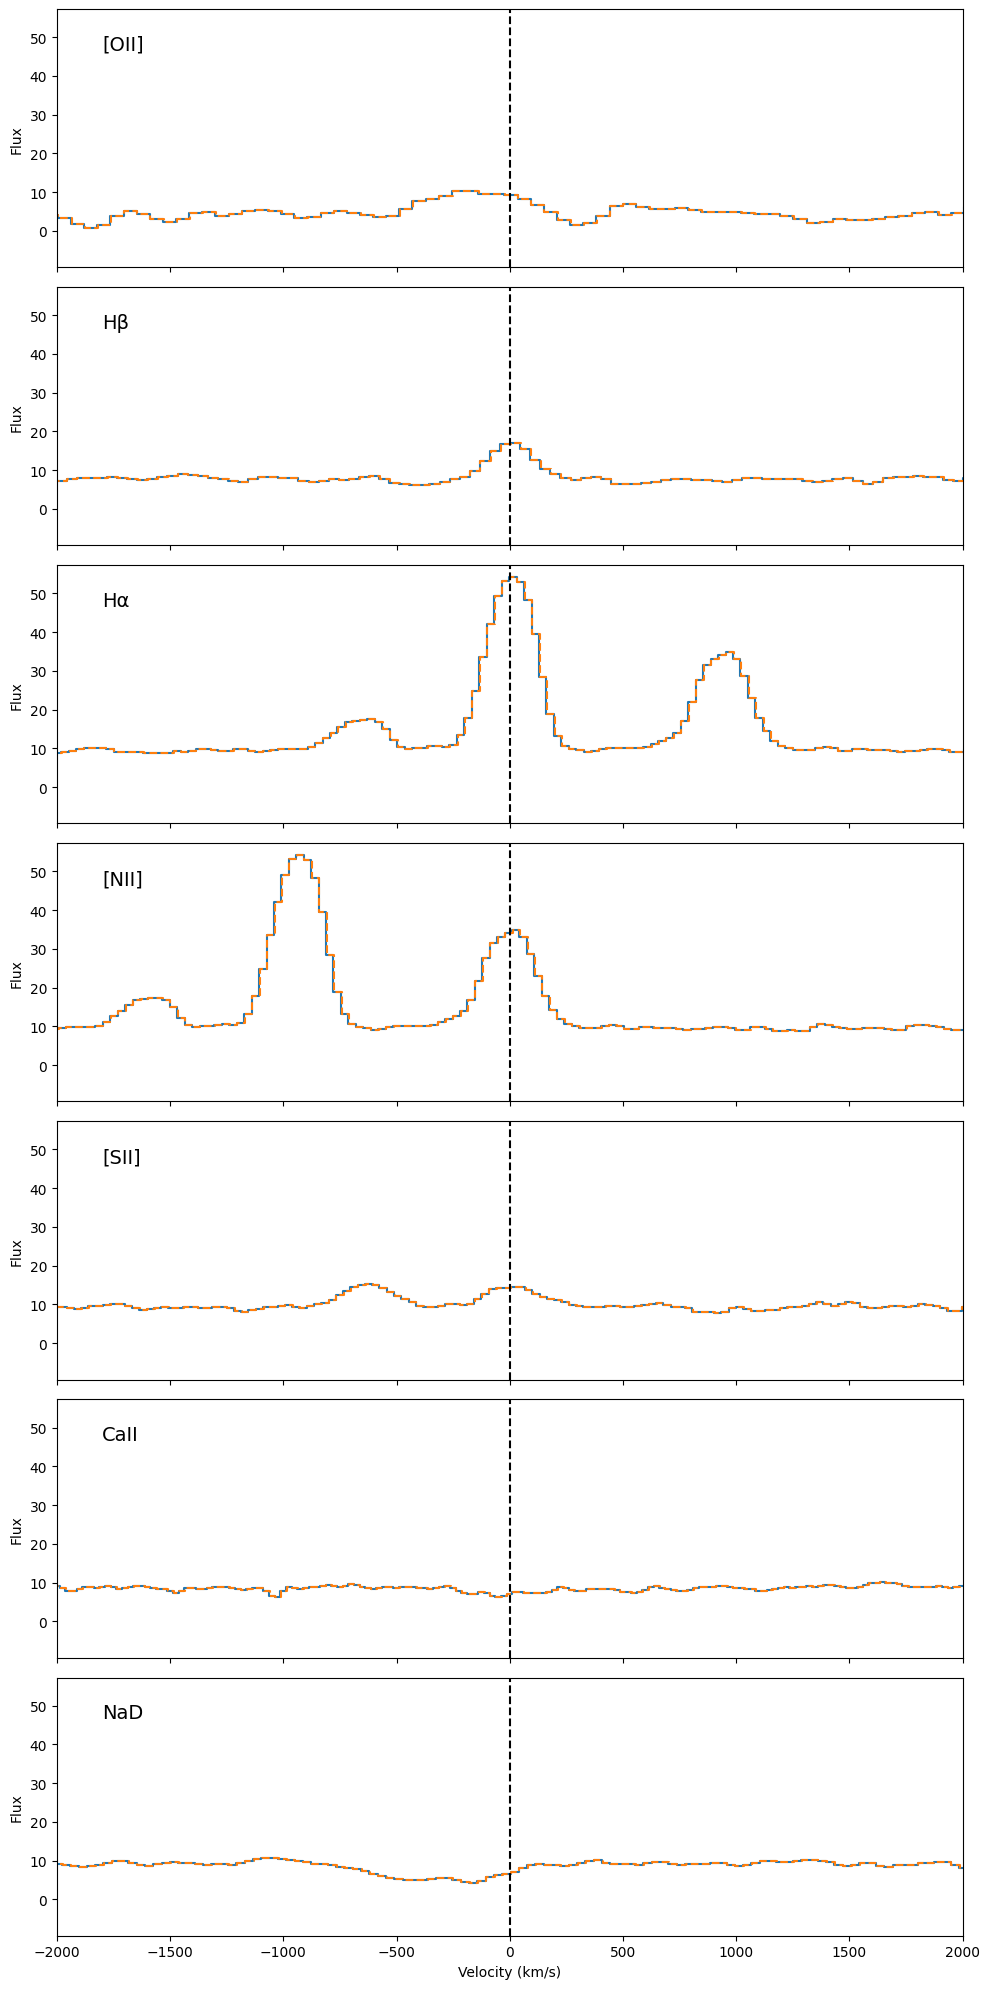

In [85]:
fig, ax = plt.subplots(7, 1, figsize=(10, 20), sharex=True)

ax[0].step(lam2vel(desi_wavelength, OII_rest[-1], z+params[0]), flux, where='mid')
ax[1].step(lam2vel(desi_wavelength, Hbeta_rest, z+params[0]), flux, where='mid')
ax[2].step(lam2vel(desi_wavelength, Halpha_rest, z+params[0]), flux, where='mid')
ax[3].step(lam2vel(desi_wavelength, NII_rest[-1], z+params[0]), flux, where='mid')
ax[4].step(lam2vel(desi_wavelength, SII_rest[-1], z+params[0]), flux, where='mid')
ax[5].step(lam2vel(desi_wavelength, CaII_rest[-1], z+params[0]), flux, where='mid')
ax[6].step(lam2vel(desi_wavelength, NaD_rest[-1], z+params[0]), flux, where='mid')

ax[0].step(lam2vel(desi_wavelength, OII_rest[-1], z), flux, where='mid', linestyle='--')
ax[1].step(lam2vel(desi_wavelength, Hbeta_rest, z), flux, where='mid', linestyle='--')
ax[2].step(lam2vel(desi_wavelength, Halpha_rest, z), flux, where='mid', linestyle='--')
ax[3].step(lam2vel(desi_wavelength, NII_rest[-1], z), flux, where='mid', linestyle='--')
ax[4].step(lam2vel(desi_wavelength, SII_rest[-1], z), flux, where='mid', linestyle='--')
ax[5].step(lam2vel(desi_wavelength, CaII_rest[-1], z), flux, where='mid', linestyle='--')
ax[6].step(lam2vel(desi_wavelength, NaD_rest[-1], z), flux, where='mid', linestyle='--')

for i in range(7):
    ax[i].text(0.05, 0.9, ['[OII]', 'Hβ', 'Hα', '[NII]', '[SII]', 'CaII', 'NaD'][i], transform=ax[i].transAxes, fontsize=14, verticalalignment='top')
    ax[i].set_xlim(-2000, 2000)
    ax[i].axvline(0, color='k', linestyle='--')
    ax[i].set_ylabel('Flux')
ax[-1].set_xlabel('Velocity (km/s)')
plt.tight_layout()
plt.show()